<a href="https://colab.research.google.com/github/angellusj/TEES/blob/main/mnist_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando bibliotecas necessárias

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
(imagens_treino_mnist, rotulos_treino_mnist), (imagens_teste_mnist, rotulos_teste_mnist) = keras.datasets.mnist.load_data()

In [3]:
imagens_treino_mnist = imagens_treino_mnist.astype('float32')/255.0
imagens_teste_mnist = imagens_teste_mnist.astype('float32')/255.0

imagens_treino_mnist = np.expand_dims(imagens_treino_mnist, -1)
imagens_teste_mnist = np.expand_dims(imagens_teste_mnist, -1)

In [4]:
TAMANHO_IMAGEM_MNIST = 28
NUM_CLASSES_MNIST = 10
TAMANHO_LOTE_MNIST = 128

dataset_treino_tf_mnist = tf.data.Dataset.from_tensor_slices((imagens_treino_mnist, rotulos_treino_mnist))

In [5]:
dataset_teste_tf_mnist = tf.data.Dataset.from_tensor_slices((imagens_teste_mnist, rotulos_teste_mnist))

In [6]:
dataset_treino_tf_mnist = dataset_treino_tf_mnist.shuffle(buffer_size=10000).batch(TAMANHO_LOTE_MNIST).prefetch(tf.data.AUTOTUNE)
dataset_teste_tf_mnist = dataset_teste_tf_mnist.batch(TAMANHO_LOTE_MNIST).prefetch(tf.data.AUTOTUNE)

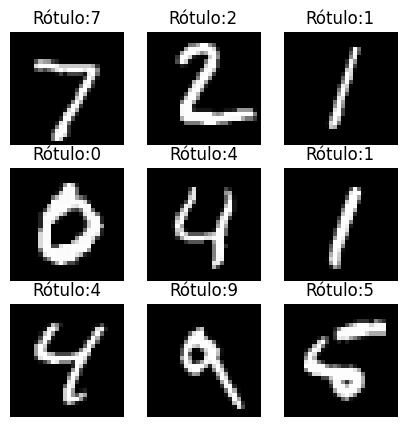

In [9]:
plt.figure(figsize=(5,5))
for i, (imagem, rotulo) in enumerate(dataset_teste_tf_mnist.unbatch().take(9)):
  ax = plt.subplot(3,3, i+1)
  plt.imshow(imagem.numpy().squeeze(), cmap = 'gray')
  plt.title(f"Rótulo:{rotulo.numpy()}")
  plt.axis("off")
plt.show()

In [13]:
modelo = keras.Sequential([
    keras.Input(shape = (TAMANHO_IMAGEM_MNIST, TAMANHO_IMAGEM_MNIST, 1)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(NUM_CLASSES_MNIST, activation='softmax')
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = modelo.fit(dataset_treino_tf_mnist,
                     validation_data=dataset_teste_tf_mnist,
                     epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9165 - loss: 0.2919 - val_accuracy: 0.9759 - val_loss: 0.0757
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9751 - loss: 0.0841 - val_accuracy: 0.9837 - val_loss: 0.0501
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9801 - loss: 0.0624 - val_accuracy: 0.9866 - val_loss: 0.0401
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9838 - loss: 0.0510 - val_accuracy: 0.9869 - val_loss: 0.0392
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9865 - loss: 0.0431 - val_accuracy: 0.9891 - val_loss: 0.0320
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9883 - loss: 0.0376 - val_accuracy: 0.9894 - val_loss: 0.0304
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9897 - loss: 0.0330 - val_accuracy: 0.9895 - val_loss: 0.0298
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.0301 - val_accuracy: 

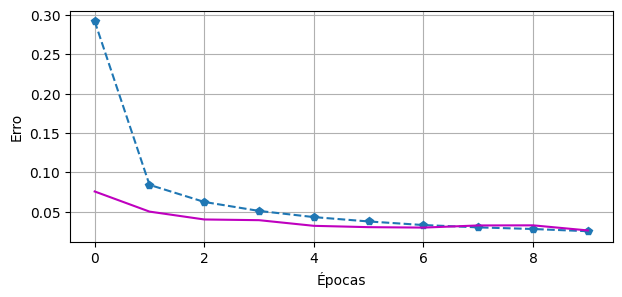

In [20]:
plt.figure(figsize=(7,3))
plt.plot(history.history['loss'], 'p--', label='Perda treino')
plt.plot(history.history['val_loss'], 'm', label ='Perda validade')
plt.ylabel('Erro')
plt.xlabel('Épocas')
plt.grid(True)

In [23]:
modelo.save('modelo_cnn_mnist.h5')
modelo.save('modelo_cnn_mnist.keras')

modelo.save_weights('modelo_cnn_mnis.weights.h5')

In [24]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.2 MB/s eta 0:00:00


In [50]:
%%writefile app.py
import streamlit as st
from PIL import Image, ImageOps
import tensorflow as tf
import numpy as np


def carregar_modelo():
  return tf.keras.models.load_model('modelo_cnn_mnist.keras', compile=False)

modelo = carregar_modelo()

st.title("Reconhecimento de Dígitos")

arquivo = st.file_uploader("Envie uma imagem do dígito (PNG/JPG)", type=["png", "jpg", "jpeg"])

if arquivo:
  img = Image.open(arquivo).convert("L")

  #inversão inteligente (evita erro dependendo da imagem)
  if np.mean(img) > 127:
    img = ImageOps.invert(img)

  img = img.resize((28,28))

  x = np.array(img, dtype=np.float32)/255.0
  x = x.reshape(1,28,28,1)

  prob = modelo.predict(x, verbose = 0)[0]
  digito = int(np.argmax(prob))

  st.image(img, width = 150)
  st.markdown(f"## Dígito: **{digito}**")
  st.markdown(f"Confiança: `{prob[digito]*100:.1f}%")

  st.bar_chart(prob)

Overwriting app.py


In [51]:
!npm install localtunnel

⠙⠹⠸⠼
up to date, audited 23 packages in 675ms
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠴

In [52]:
!streamlit run /content/app.py &>/content/logs.txt &

In [53]:
!npx localtunnel --port 8501

⠙your url is: https://sad-friends-lose.loca.lt
^C
